In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías necesarias y del dataset resultante de `01_eda.ipynb`, ya limpio (`data/processed/sevilla/listings_full_clean.csv`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/processed/sevilla/listings_full_clean.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_license
0,1309470637323585850,https://www.airbnb.com/rooms/1309470637323585850,20260630144934,2026-07-01,city scrape,Hispalis Conde de Ibarra,Enjoy the simplicity of this quiet and central...,https://a0.muscache.com/pictures/miso/Hosting-...,105842350,https://www.airbnb.com/users/show/105842350,...,NaN,NaN,NaN,Andalucia - Regional registration number<br />...,49,49,0,0,0.00,True
1,1289724071413626873,https://www.airbnb.com/rooms/1289724071413626873,20260630144934,2026-07-03,previous scrape,Casco Antiguo - Alameda,Fully equipped and decorated apartment in the ...,https://a0.muscache.com/pictures/miso/Hosting-...,204455,https://www.airbnb.com/users/show/204455,...,5.0,5.0,5.0,Andalucia - Regional registration number<br />...,1,1,0,0,0.15,True
2,1339192260517471999,https://www.airbnb.com/rooms/1339192260517471999,20260630144934,2026-07-03,previous scrape,Habitación cama doble,Room for 2 people but it is large and an extra...,https://a0.muscache.com/pictures/hosting/Hosti...,669165477,https://www.airbnb.com/users/show/669165477,...,NaN,NaN,NaN,Sin licencia,2,0,2,0,0.00,False
3,1639896774876721901,https://www.airbnb.com/rooms/1639896774876721901,20260630144934,2026-07-01,city scrape,La Antigua Alfalfa 8,You'll enjoy your time at this cheerful getaway.,https://a0.muscache.com/pictures/prohost-api/H...,662331781,https://www.airbnb.com/users/show/662331781,...,5.0,5.0,5.0,Andalucia - Regional registration number<br />...,25,14,11,0,1.25,True
4,1024783687633067957,https://www.airbnb.com/rooms/1024783687633067957,20260630144934,2026-07-01,city scrape,Habitaciones plaza salva,Enjoy the simplicity of this quiet and central...,https://a0.muscache.com/pictures/hosting/Hosti...,546532895,https://www.airbnb.com/users/show/546532895,...,4.0,5.0,5.0,Andalucia - Regional registration number<br />...,1,0,1,0,0.04,True


## 2. Selección de variables de partida

De las 78 columnas del dataset limpio, decidir cuáles se descartan antes de construir features (identificadores, URLs, texto libre sin procesar, columnas redundantes dentro de una misma familia) y cuáles se mantienen como base. Mismo criterio que en las otras cuatro ciudades.

Se descartan seis grupos de columnas antes de construir ninguna feature:

1. **URLs y metadatos de scraping**: `listing_url`, `picture_url`, `host_url`, `host_profile_url`, `host_picture_url`, `scrape_id`, `last_scraped`, `source`, `calendar_last_scraped`. No describen el alojamiento.
2. **Texto libre sin procesar**: `name`, `description`, `host_about`, `host_location`. `amenities` es distinto: se trata aparte en la sección 9 (flags por palabra clave), no se descarta aquí.
3. **Columnas que ya cumplieron su función**: `bathrooms_text` (ya se extrajo `bathrooms`), `license` (ya existe `has_license`), `host_name` (identificador) y `host_listings_count` (redundante con `calculated_host_listings_count`, recalculado sobre el propio dataset).
4. **`price_quote_*`**: se comprueba a continuación por qué se descartan.
5. **Familias redundantes** detectadas en la EDA: variantes de `minimum_nights`/`maximum_nights`, de `availability`, y las ventanas de reviews más finas (`number_of_reviews_l30d`, `number_of_reviews_ly`).
6. **`estimated_revenue_l365d`**: riesgo de fuga de información, se comprueba también a continuación.

#### ¿Por qué se descarta `price_quote_*`?

`price_quote_price_per_night` coincide con `price` en el 99.99% de las filas (la fracción residual son los pocos casos vistos en la EDA sección 8.2 donde la cotización se consultó para fechas/condiciones ligeramente distintas), y `price_quote_raw` es el JSON de esa misma cotización. No es información nueva.

In [3]:
(df["price"] == df["price_quote_price_per_night"]).mean()

np.float64(0.999869109947644)

#### ¿Por qué se descarta `estimated_revenue_l365d`?

Se calcula multiplicando `price` por `estimated_occupancy_l365d`. Usarla como feature sería fuga de información.

In [4]:
(df["price"] * df["estimated_occupancy_l365d"]).corr(df["estimated_revenue_l365d"])

np.float64(0.9999999999673181)

#### ¿Por qué se descartan `name`, `description`, `host_about` y `host_location`?

Texto libre sin estructura: la parte objetiva (tamaño, ubicación, equipamiento) ya está en columnas estructuradas, y sacar señal de texto de verdad requeriría NLP para un beneficio incierto. Se descartan de forma definitiva, igual que en las otras cuatro ciudades.

#### Aplicando los descartes

In [5]:
drop_cols = [
    # URLs y metadatos de scraping
    "listing_url", "picture_url", "host_url", "host_profile_url", "host_picture_url",
    "scrape_id", "last_scraped", "source", "calendar_last_scraped",
    # texto libre sin procesar (amenities NO va aquí: se procesa en la sección 9)
    "name", "description", "host_about", "host_location",
    # columnas que ya cumplieron su función
    "bathrooms_text", "license", "host_name", "host_listings_count",
    # price_quote_* (redundante con price)
    "price_quote_checkin_date", "price_quote_checkout_date", "price_quote_total_price",
    "price_quote_price_per_night", "price_quote_raw",
    # familias redundantes de estancia
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    # familia redundante de disponibilidad
    "availability_30", "availability_60", "availability_90", "availability_eoy",
    # ventanas de reviews más finas
    "number_of_reviews_l30d", "number_of_reviews_ly",
    # fuga de información
    "estimated_revenue_l365d",
]

df = df.drop(columns=drop_cols)
df.shape

(7640, 43)

Quedan 43 columnas de partida, exactamente igual que en las otras cuatro ciudades (mismo esquema original). `id`, `host_id` y `host_profile_id` se mantienen como identificadores de referencia. `amenities` se deja para la sección 9. El resto son las que se transforman en las siguientes secciones.

In [6]:
df.columns.tolist()

['id',
 'host_id',
 'host_profile_id',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'has_lice

## 3. Transformaciones numéricas

Logaritmos y ratios sobre las variables numéricas con distribución muy asimétrica y sobre las variables de tamaño.

### 3.1 Logaritmos

En la EDA se midió la asimetría de cada variable numérica. Se aplica `log1p` a las que tienen un coeficiente de asimetría alto: `price` (18.2, la más asimétrica con diferencia), `calculated_host_listings_count` (3.1), `bathrooms` (3.0), `beds` (2.6), `number_of_reviews` (2.7), `bedrooms` (2.1, más baja que en la EDA porque ya no incluye la fila corregida en la EDA sección 8.3), `number_of_reviews_ltm` (2.0) y `reviews_per_month` (1.9). Se guardan como columnas nuevas con sufijo `_log`, sin sustituir a las originales.

In [7]:
log_vars = [
    "price", "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "bedrooms", "beds", "bathrooms", "calculated_host_listings_count",
]

for c in log_vars:
    df[f"{c}_log"] = np.log1p(df[c])

Se comprueba el efecto sobre `price`, la más asimétrica de todas.

Text(0.5, 1.0, 'price_log')

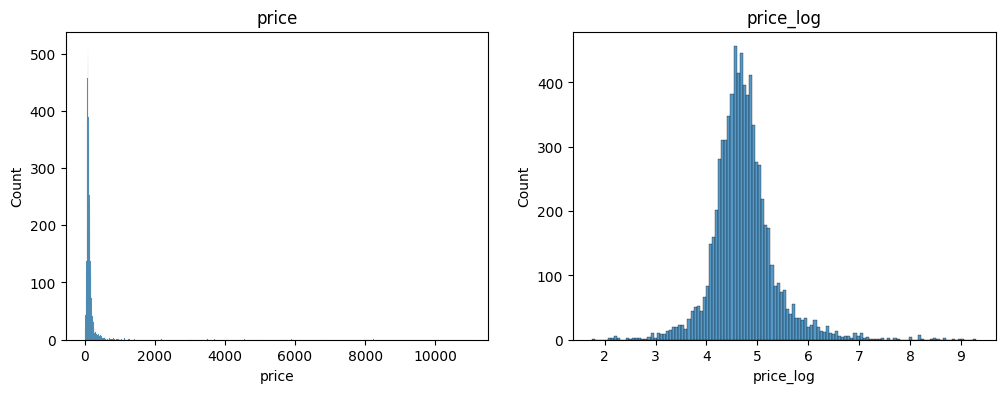

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df, x="price", ax=axes[0])
axes[0].set_title("price")
sns.histplot(df, x="price_log", ax=axes[1])
axes[1].set_title("price_log")

La distribución pasa de una cola muy larga a una forma mucho más cercana a la normal, igual que en las otras ciudades.

### 3.2 Ratios

`price_per_accommodate` normaliza el precio por la capacidad del alojamiento. Se usa `accommodates` como denominador porque nunca vale 0. `price_per_min_night` es el mismo ratio que en las otras ciudades, aplicado aquí.

In [9]:
df["price_per_accommodate"] = df["price"] / df["accommodates"]
df["price_per_min_night"] = df["price"] / df["minimum_nights"]

df[["price_per_accommodate", "price_per_min_night"]].describe()

,price_per_accommodate,price_per_min_night
count,7640.000000,7640.000000
mean,41.082949,113.444702
std,76.193589,270.340671
min,2.250000,0.053111
25%,22.697917,47.168750
50%,30.500000,76.940000
75%,42.176250,121.583750
max,2449.750000,10970.000000


<Axes: xlabel='price_per_accommodate', ylabel='Count'>

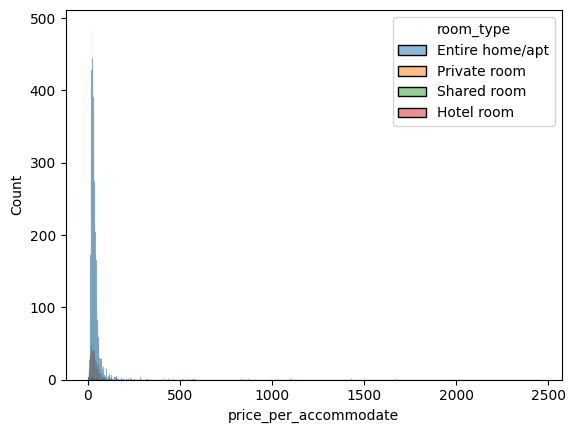

In [10]:
sns.histplot(df, x="price_per_accommodate", hue="room_type")

## 4. Variables de tamaño: multicolinealidad

`accommodates`, `bedrooms`, `beds` y `bathrooms` están correlacionadas entre sí. Decidir si se mantienen todas, se combinan en un índice, o se descarta alguna.

La correlación entre estas cuatro (0.57-0.81) es la más alta de las cinco ciudades a simple vista. Se calcula el VIF (Variance Inflation Factor): a partir de 5, y sobre todo de 10, se considera multicolinealidad seria.

In [11]:
size_vars = ["accommodates", "bedrooms", "beds", "bathrooms"]

corr_matrix = df[size_vars].corr().values
vif = np.diag(np.linalg.inv(corr_matrix))

pd.Series(vif, index=size_vars, name="VIF")

accommodates    3.707302
bedrooms        3.783149
beds            3.441830
bathrooms       1.847685
Name: VIF, dtype: float64

Los cuatro VIF están entre 1.8 y 3.8 — más altos que en Valencia (1.3-2.7), pero todavía por debajo del umbral de 5. `bathrooms` vuelve a ser la que menos se solapa con las otras tres (VIF 1.85), y `bedrooms` la que más (VIF 3.78). Se mantienen las cuatro tal cual, sin combinarlas ni descartar ninguna.

Como en las otras ciudades, esto solo importaría de verdad para un modelo lineal. Si más adelante los coeficientes de estas variables salen inestables entre folds, este es el sitio al que volver — con Sevilla siendo la ciudad donde más vigilancia merece, al tener el VIF más alto de las cinco.

## 5. Codificación de categóricas

`room_type`, `neighbourhood_group_cleansed`, `neighbourhood_cleansed` y `property_type`: agrupar categorías raras donde haga falta y codificar.

Las cuatro necesitan tratamientos distintos según su cardinalidad: `room_type` y `neighbourhood_group_cleansed` son pocas categorías y se codifican directamente; `neighbourhood_cleansed` (102 barrios) y `property_type` (42 tipos) tienen demasiadas para un one-hot directo.

### 5.1 `room_type`

4 categorías sin orden natural: one-hot encoding.

In [12]:
df = pd.get_dummies(df, columns=["room_type"], prefix="room_type")

### 5.2 `neighbourhood_group_cleansed`

11 categorías (los distritos de Sevilla): mismo tratamiento.

In [13]:
df = pd.get_dummies(df, columns=["neighbourhood_group_cleansed"], prefix="district")

### 5.3 `neighbourhood_cleansed`

102 categorías: un one-hot directo generaría 102 columnas casi todas dispersas, más que en ninguna otra ciudad. Se usa **target encoding suavizado**: cada barrio se sustituye por su precio medio, mezclado con el precio medio global cuando el barrio tiene pocos anuncios.

**Aviso importante**: esta media se calcula aquí con todo el dataset, solo para tener la columna disponible y poder seguir explorando en el resto de este notebook — no es la versión final. Antes de entrenar un modelo de verdad hay que recalcularla usando únicamente los datos de entrenamiento, o se estaría filtrando información del conjunto de test al de entrenamiento. Por eso `neighbourhood_cleansed` (la columna cruda) se mantiene más allá de la limpieza final de la sección 10, en vez de descartarse aquí mismo: la corrección real ocurre en `03_model_baseline.ipynb`, justo después del split.

In [14]:
global_mean_price = df["price"].mean()
neigh_stats = df.groupby("neighbourhood_cleansed")["price"].agg(["mean", "count"])

smoothing = 10
smoothed_mean = (neigh_stats["count"] * neigh_stats["mean"] + smoothing * global_mean_price) / (neigh_stats["count"] + smoothing)

df["neighbourhood_price_encoded"] = df["neighbourhood_cleansed"].map(smoothed_mean)

In [15]:
df[["neighbourhood_cleansed", "neighbourhood_price_encoded"]].drop_duplicates().sort_values("neighbourhood_price_encoded", ascending=False).head(10)

,neighbourhood_cleansed,neighbourhood_price_encoded
40,El Porvenir,220.302101
146,El Gordillo,219.332090
18,Triana Oeste,199.859281
14,Triana Casco Antiguo,180.013311
114,El Carmen,179.894662
249,El Cerro,176.353493
46,La Buhaira,174.661034
484,"El Juncal, Híspalis",172.442617
3,Alfalfa,172.011807
160,Heliópolis,171.842963


`El Porvenir` y `El Gordillo` encabezan la lista, seguidos de cerca por los tres barrios de `Triana` (`Triana Oeste`, `Triana Casco Antiguo`) y `El Carmen`: zonas residenciales de nivel alto y el centro histórico de Triana, no el `Casco Antiguo` propiamente dicho (que en la EDA sección 9 ya salió en mitad de tabla pese a ser, con diferencia, el distrito más numeroso).

### 5.4 `property_type`

42 categorías, muy concentradas: `Entire rental unit` y `Private room in rental unit` son el 79.3% del dataset, y 30 de las 42 categorías tienen menos de 30 anuncios. Igual que en las otras ciudades, aquí sí interesa agrupar en "Otros" antes de codificar: tras agrupar quedan 13 categorías (12 propias + `Other`), un one-hot manejable.

In [16]:
property_type_counts = df["property_type"].value_counts()
rare_property_types = property_type_counts[property_type_counts < 30].index

df["property_type_grouped"] = df["property_type"].where(
    ~df["property_type"].isin(rare_property_types), "Other"
)
df["property_type_grouped"].nunique()

13

In [17]:
df = pd.get_dummies(df, columns=["property_type_grouped"], prefix="property_type")

Con esto, `room_type`, `neighbourhood_group_cleansed` y `property_type_grouped` quedan como columnas binarias, y `neighbourhood_cleansed` como una única columna numérica (`neighbourhood_price_encoded`). `property_type` (texto) se descarta en la limpieza final de la sección 10. `neighbourhood_cleansed` (texto) se mantiene hasta después del split en `03_model_baseline.ipynb`, como se explicó en 5.3.

## 6. Variables derivadas del host

Señales sobre el tipo de host a partir de `calculated_host_listings_count`, `host_is_superhost` y la antigüedad.

### 6.1 Antigüedad del host

In [18]:
df["host_tenure_years"] = df["hosts_time_as_host_years"] + df["hosts_time_as_host_months"] / 12
df["host_tenure_years"].describe()

count    7640.000000
mean        7.280137
std         3.856050
min         0.000000
25%         4.000000
50%         7.791667
75%        10.166667
max        15.416667
Name: host_tenure_years, dtype: float64

### 6.2 Tamaño del host

Antes de convertir `calculated_host_listings_count` en un flag binario, se comprueba qué umbral tendría sentido.

In [19]:
for threshold in [1, 2, 5, 10]:
    pct = (df["calculated_host_listings_count"] > threshold).mean() * 100
    print(f"más de {threshold} anuncios: {pct:.1f}%")

más de 1 anuncios: 76.7%
más de 2 anuncios: 67.0%
más de 5 anuncios: 50.9%
más de 10 anuncios: 38.3%


Con `> 1` ya se marca al 76.7% como "profesional" (la mediana de `calculated_host_listings_count` es 6, la más alta de las cinco ciudades: el mercado sevillano está más dominado por hosts con carteras grandes que Valencia o Málaga). Un flag binario no distingue lo suficiente. Se construyen las mismas 4 categorías que en las otras ciudades, por umbrales redondos: `individual` (1 anuncio), `pequeno` (2-10), `mediano` (11-50) y `grande` (51+).

In [20]:
bins = [0, 1, 10, 50, df["calculated_host_listings_count"].max()]
labels = ["individual", "pequeno", "mediano", "grande"]
df["host_size_tier"] = pd.cut(df["calculated_host_listings_count"], bins=bins, labels=labels)

df.groupby("host_size_tier", observed=True)["price"].agg(["count", "median"])

,count,median
host_size_tier,,
individual,1779,108.410
pequeno,2938,103.625
mediano,1991,107.500
grande,932,119.100


No monótona (108.41€ → 103.63€ → 107.50€ → 119.10€): baja de `individual` a `pequeno` y solo vuelve a subir a partir de `mediano`, un patrón en "U" que no se había visto en las otras ciudades. Se codifica con one-hot, igual que en las otras cuatro: no tiene sentido asumir un orden numérico que ni siquiera aquí se cumple.

In [21]:
df = pd.get_dummies(df, columns=["host_size_tier"], prefix="host_size")

### 6.3 Composición del portfolio del host

`calculated_host_listings_count_entire_homes` frente al total del host: qué proporción de los anuncios de ese host son pisos enteros.

In [22]:
df["host_entire_homes_ratio"] = (
    df["calculated_host_listings_count_entire_homes"] / df["calculated_host_listings_count"]
)
df["host_entire_homes_ratio"].corr(df["price"])

np.float64(0.06770564027550988)

Solo 0.07 de correlación con `price`, apenas por encima de la del propio `calculated_host_listings_count` (0.03) — a diferencia de Valencia (0.27 vs. 0.08), en Sevilla ni el tamaño del host ni la composición de su portfolio aportan gran cosa sobre el precio. Se mantiene igualmente por consistencia entre modelos, sin expectativas altas.

## 7. Variables derivadas de reviews

Señales a partir de `review_scores_rating` y compañía, teniendo en cuenta que una parte de los anuncios no tiene reviews todavía.

### 7.1 `has_reviews`

El 6.7% de los anuncios no tiene reviews todavía, la proporción más baja de las cinco ciudades. Se deja explícito con un flag.

In [23]:
df["has_reviews"] = df["number_of_reviews"] > 0
df["has_reviews"].value_counts()

has_reviews
True     7129
False     511
Name: count, dtype: int64

### 7.2 Antigüedad y recencia de reviews

Se usa la `last_review` más reciente de todo el dataset como fecha de referencia ('hoy' aproximado).

In [24]:
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])

reference_date = df["last_review"].max()
df["listing_age_days"] = (reference_date - df["first_review"]).dt.days
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days

df[["listing_age_days", "days_since_last_review"]].describe()

,listing_age_days,days_since_last_review
count,7129.000000,7129.000000
mean,1581.438350,130.190630
std,1224.610332,325.537827
min,1.000000,0.000000
25%,568.000000,12.000000
50%,1272.000000,25.000000
75%,2505.000000,72.000000
max,5602.000000,4992.000000


In [25]:
df["listing_age_days"].corr(df["price"]), df["days_since_last_review"].corr(df["price"])

(np.float64(-0.01632188256791112), np.float64(0.09553486566290076))

Ambas quedan `NaN` para los anuncios sin reviews, coherente con `has_reviews`. `listing_age_days` prácticamente no correlaciona (-0.02), pero `days_since_last_review` sí sube algo (0.10, más que en las otras ciudades): los anuncios más caros llevan más tiempo sin recibir una reseña nueva, coherente con la correlación negativa de `number_of_reviews`/`reviews_per_month` ya vista en la EDA (rotan menos huéspedes al año). Se mantienen ambas: son información real que antes estaba encerrada en un texto de fecha.

### 7.3 Los 6 subscores de review

Correlacionan entre 0.58 y 0.86 con `review_scores_rating`, y tienen prácticamente los mismos nulos. Misma redundancia que ya se resolvió con las familias de la sección 2: se conserva `review_scores_rating` como resumen y se descartan los 6 subscores.

In [26]:
df = df.drop(columns=[
    "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location", "review_scores_value",
])

`review_scores_rating` se deja como `NaN` para los anuncios sin reviews, sin imputar: en la EDA salía prácticamente sin correlación en Pearson (-0.001) y modesta en Spearman (0.20), inventar un valor no aportaría nada de forma fiable.

## 8. Variables geográficas

Alguna codificación adicional de `latitude`/`longitude` más allá del barrio.

### 8.1 Distancia al centro

`neighbourhood_price_encoded` (sección 5) es discreta: dos anuncios muy cerca pero a cada lado de la frontera de un barrio tendrían valores distintos sin motivo real. La distancia en línea recta al centro (la Catedral de Sevilla, referencia habitual de la ciudad) da una versión continua del mismo patrón espacial.

In [27]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

center_lat, center_lon = 37.3826, -5.9963  # Catedral de Sevilla
df["distance_to_center_km"] = haversine(df["latitude"], df["longitude"], center_lat, center_lon)

df["distance_to_center_km"].describe()

count    7640.000000
mean        1.410088
std         1.000288
min         0.019231
25%         0.818621
50%         1.193393
75%         1.715236
max         9.631738
Name: distance_to_center_km, dtype: float64

In [28]:
df["distance_to_center_km"].corr(df["price"]), df["distance_to_center_km"].corr(df["neighbourhood_price_encoded"])

(np.float64(-0.04501534832270186), np.float64(-0.43199239628207475))

Un patrón parecido a Barcelona, no a Valencia: la correlación directa con `price` es débil (-0.05), pero con `neighbourhood_price_encoded` es fuerte (-0.43, casi idéntica a Barcelona). Tiene sentido con lo ya visto en la EDA: Sevilla sí tiene una geografía de precio centrada en el casco histórico y sus alrededores inmediatos (`El Porvenir`, `Triana`), sin los dos polos enfrentados de Valencia (centro + playa) que cancelaban parte del efecto. La correlación directa con `price` es débil porque, dentro de cada barrio, el precio varía mucho más por tamaño que por la posición exacta (sección 10 de la EDA); a nivel de barrio agregado, el gradiente centro-periferia sí es real y fuerte.

Text(0, 0.5, 'log1p(price)')

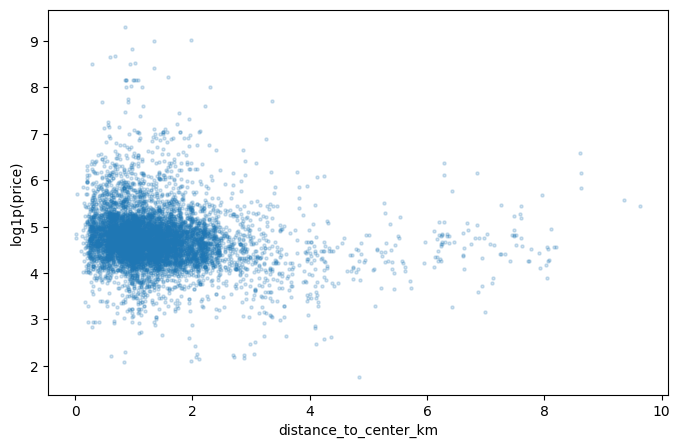

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(df["distance_to_center_km"], np.log1p(df["price"]), s=5, alpha=0.2)
plt.xlabel("distance_to_center_km")
plt.ylabel("log1p(price)")

La nube de puntos muestra mucha dispersión vertical a cualquier distancia, coherente con una correlación directa débil: el efecto geográfico existe pero queda enmascarado por la variabilidad de tamaño/tipo de anuncio a nivel individual.

### 8.2 Densidad de anuncios cercanos

Motivado en la sección 11.5 de la EDA: cuántos otros anuncios reales hay en un radio de 150 metros de cada uno.

In [30]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
df["n_nearby_150m"] = counts - 1  # excluir el propio anuncio

df["n_nearby_150m"].describe()

count    7640.000000
mean      105.207592
std        65.854434
min         0.000000
25%        54.750000
50%       106.000000
75%       153.000000
max       266.000000
Name: n_nearby_150m, dtype: float64

Mismo resultado que en la EDA (media ~105, mediana 106): correlación casi nula con `price` (0.03), la más débil de las cinco ciudades. Se mantiene igualmente por consistencia entre modelos, sin expectativas de aporte real.

## 9. Amenities

Se construyen las cuatro variables motivadas en la sección 12 de la EDA: `has_ac`, `has_pool` y `has_dishwasher` (flags por palabra clave) y `n_amenities` (recuento total). Un one-hot directo de las 1755 categorías de `amenities` no es viable (55.9% son variantes que aparecen una sola vez).

### 9.1 Parsear y construir los flags

In [31]:
import ast

amenities_parsed = df["amenities"].apply(ast.literal_eval)

def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

df["has_ac"] = amenities_parsed.apply(lambda l: has_any(l, ["air condition", "ac - "]))
df["has_pool"] = amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"]))
df["has_dishwasher"] = amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"]))
df["n_amenities"] = amenities_parsed.apply(len)

df[["has_ac", "has_pool", "has_dishwasher", "n_amenities"]].describe()

,n_amenities
count,7640.000000
mean,32.804712
std,12.811198
min,0.000000
25%,24.000000
50%,33.000000
75%,42.000000
max,90.000000


Prevalencias consistentes con la EDA (`has_ac` ~95.7%, `has_dishwasher` ~40.2%, `has_pool` ~10.2%, `n_amenities` media ~32.8). A diferencia de Valencia y Málaga, ninguna de las tres destaca especialmente: en la EDA todas salían con correlaciones débiles (`has_dishwasher` 0.064, `has_pool` 0.052, `has_ac` 0.013), las más bajas de las cinco ciudades. Se construyen igualmente por consistencia, sin priorizar ninguna sobre las demás.

### 9.2 Descartar `amenities`

Ya cumplió su función: se descarta el texto crudo.

In [32]:
df = df.drop(columns=["amenities"])
df.shape

(7640, 88)

## 10. Dataset final para modelado

Selección de las columnas finales y guardado en `data/processed/sevilla/` para los notebooks de modelado.

### 10.1 Un último cabo suelto: `hosts_time_as_user_*`

En la sección 6 se combinó la antigüedad como host, pero se quedó sin tocar la antigüedad como usuario de Airbnb en general. Se combina igual, por coherencia.

In [33]:
df["host_user_tenure_years"] = df["hosts_time_as_user_years"] + df["hosts_time_as_user_months"] / 12

### 10.2 Limpieza final

Se descartan las columnas ya sustituidas por una versión mejor: `property_type` en texto, las cuatro columnas de antigüedad ya combinadas, `first_review`/`last_review` en formato fecha, y el desglose `calculated_host_listings_count_entire_homes`/`_private_rooms`/`_shared_rooms` (ya resumido en `host_entire_homes_ratio`).

`neighbourhood_cleansed` es la excepción, no se descarta aquí: se mantiene para que `03_model_baseline.ipynb` recalcule `neighbourhood_price_encoded` solo con train justo después del split.

In [34]:
final_drop = [
    "property_type",
    "hosts_time_as_host_years", "hosts_time_as_host_months",
    "hosts_time_as_user_years", "hosts_time_as_user_months",
    "first_review", "last_review",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

df = df.drop(columns=final_drop)
df.shape

(7640, 79)

### 10.3 Comprobación de nulos

Debería quedar solo lo que se dejó así a propósito: todo lo relacionado con anuncios sin reviews todavía.

In [35]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

review_scores_rating      511
listing_age_days          511
days_since_last_review    511
dtype: int64

Las tres coinciden exactamente en las mismas 511 filas (`has_reviews == False`), tal y como se esperaba. No hace falta ninguna acción más.

### 10.4 Identificadores, objetivo y features

`id`, `host_id` y `host_profile_id` son referencias, no entran como input del modelo; `price` es la variable objetivo; `neighbourhood_cleansed` viaja en el CSV pero todavía no es una feature (pendiente de la corrección de fuga en `03_model_baseline.ipynb`); el resto son las features.

In [36]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
pending_cols = ["neighbourhood_cleansed"]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + pending_cols]

print("identificadores:", len(id_cols))
print("objetivo:", target_col)
print("pendiente de la corrección de fuga (03_model_baseline.ipynb):", len(pending_cols))
print("features:", len(feature_cols))

identificadores: 3
objetivo: price
pendiente de la corrección de fuga (03_model_baseline.ipynb): 1
features: 74


79 columnas en total: 3 identificadores, 1 objetivo, 1 pendiente y **74 features**, algo menos que en Valencia (84) pese a tener más barrios — la diferencia viene de tener también menos distritos (11 dummies de `district_*` frente a los 19 de Valencia) y menos categorías de `property_type` tras agrupar (13 frente a 15).

### 10.5 Exportar

In [37]:
df.to_csv(f"{PROJECT_DIR}/data/processed/sevilla/listings_full_features.csv", index=False)